In [1]:
import conntility
import numpy
import pandas

root_path = "/Users/natali_obi_account/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"

M_full = conntility.ConnectivityMatrix.from_h5(
    root_path+"Shapson_Coe_et_al_human_all_somas.h5",
    group_name="compressed"
)
is_H01 = True


In [2]:
if is_H01:
    # H01 dataset: Included non-neuronal cells
    M_full = M_full.index("celltype").isin(["PYRAMIDAL", "INTERNEURON", "UNCLASSIFIED_NEURON"])
    M_full.vertices["celltype"].value_counts()
    # H01 dataset: non-scaled coordinates
    M_full._vertex_properties["x"] *= (8. * 1E-3)
    M_full._vertex_properties["y"] *= (8. * 1E-3)
    M_full._vertex_properties["z"] *= (33. * 1E-3)

In [3]:
M = M_full.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")

In [4]:
def bootstrapping_overexpression(nrec, ncon, npairs):
    nrec = numpy.array(nrec)
    ncon = numpy.array(ncon)
    npairs = numpy.array(npairs)

    rnd = numpy.random.choice(len(nrec), 200 * 1000).reshape((200, 1000))

    pcon = ncon[rnd].sum(axis=1) / npairs[rnd].sum(axis=1)
    prec = nrec[rnd].sum(axis=1) / npairs[rnd].sum(axis=1)

    return prec.mean(), prec.std(), pcon.mean(), pcon.std()

In [5]:
import tqdm

def patch_clamp_sampling_at_scale(M, scale):
    xy_slice = ["slice_x", "slice_y"]
    res = []
    prec = []
    mv_cv = numpy.array([[scale, 0.0],
                        [0.0, scale]]) ** 2

    npairs = []
    ncon = []
    nrec = []
    npatch = 12

    for _ in tqdm.tqdm(numpy.arange(250)):
        mv_mn = numpy.array([0., 0.])
        try:
            smpl = M.patch_sample(npatch, mv_mn, mv_cv, columns_xy=xy_slice)
            npairs.append(len(smpl) * (len(smpl) - 1))
            ncon.append(len(smpl.edges))
            nrec.append(len(smpl.to_reciprocal().edges))
        except:
            pass
    return bootstrapping_overexpression(nrec, ncon, npairs)


In [6]:
prec_mn, prec_sd, pcon_mn, pcon_sd = patch_clamp_sampling_at_scale(M, 120.0)

prec_exp_mn = pcon_mn ** 2
prec_exp_sd = prec_sd ** 2

100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [00:01<00:00, 147.22it/s]


Text(0, 0.5, 'Connection probability')

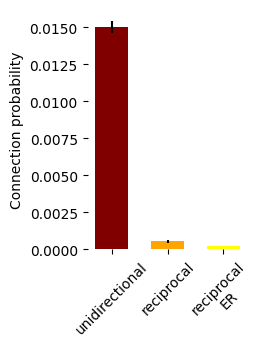

In [7]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(2, 3))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.bar([0], [pcon_mn], color="maroon", width=0.6)
ax.errorbar([0], [pcon_mn], yerr=[pcon_sd], color="black")

ax.bar([1], [prec_mn], color="orange", width=0.6)
ax.errorbar([1], [prec_mn], yerr=[prec_sd], color="black")

ax.bar([2], [prec_exp_mn], color="yellow", width=0.6)
ax.errorbar([2], [prec_exp_mn], yerr=[prec_exp_sd], color="black")

ax.set_xticks([0, 1, 2]); ax.set_frame_on(False)
ax.set_xticklabels(["unidirectional", "reciprocal", "reciprocal\nER"], rotation=45.)
ax.set_ylabel("Connection probability")

#fig.savefig("Supp_sampled_connectivity_for_em_H01.svg")